In [14]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [15]:
edf_path = Path("../data/eegmmidb/files/S001/S001R04.edf")

raw = mne.io.read_raw_edf(
    edf_path,
    preload=False,
    verbose=False
)

print(raw.info["sfreq"])

160.0


In [16]:
events, event_id = mne.events_from_annotations(raw)

print("Event IDs:")
print(event_id)

print("\nNumber of events:")
print(len(events))

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Event IDs:
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}

Number of events:
30


In [17]:
normalized_data = np.load(
    "../processed/S001_R04_preprocessed.npy"
)

print(normalized_data.shape)

(27, 20000)


In [18]:
movement_events = events[
    np.isin(
        events[:, 2],
        [event_id["T1"], event_id["T2"]]
    )
]

print(movement_events.shape)
print(movement_events[:5])

(15, 3)
[[ 672    0    3]
 [2000    0    2]
 [3328    0    2]
 [4656    0    3]
 [5984    0    3]]


In [19]:
t1_count = np.sum(
    movement_events[:,2] == event_id["T1"]
)

t2_count = np.sum(
    movement_events[:,2] == event_id["T2"]
)

print("T1:", t1_count)
print("T2:", t2_count)

T1: 8
T2: 7


In [20]:
segment_length = 320

segments = []
labels = []

for event in movement_events:

    start = event[0]
    end = start + segment_length

    if end <= normalized_data.shape[1]:

        segment = normalized_data[:, start:end]

        segments.append(segment)

        labels.append(event[2])

segments = np.array(segments)
labels = np.array(labels)

In [21]:
print("Segments shape:", segments.shape)
print("Labels shape:", labels.shape)

Segments shape: (15, 27, 320)
Labels shape: (15,)


In [22]:
print(labels)

print("\nUnique labels:")
print(np.unique(labels, return_counts=True))

[3 2 2 3 3 2 3 2 3 2 2 3 2 3 2]

Unique labels:
(array([2, 3]), array([8, 7]))


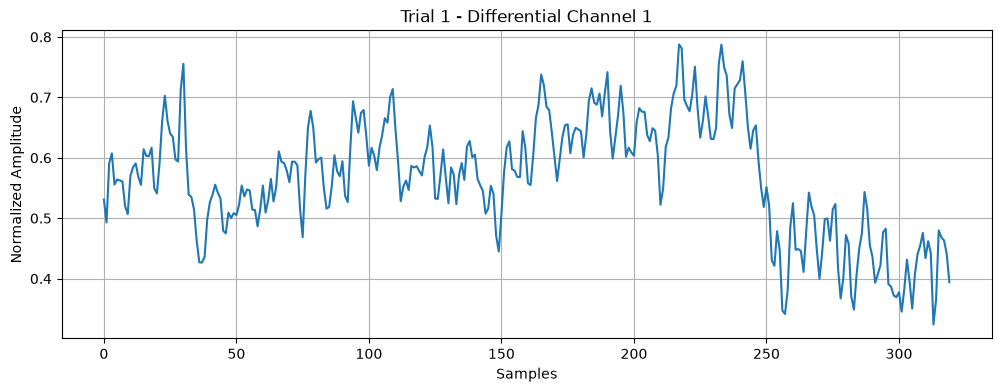

In [23]:
plt.figure(figsize=(12,4))

plt.plot(segments[0,0,:])

plt.title("Trial 1 - Differential Channel 1")
plt.xlabel("Samples")
plt.ylabel("Normalized Amplitude")

plt.grid()

plt.show()

In [24]:
labels_binary = np.where(
    labels == event_id["T1"],
    0,
    1
)

print(labels_binary)

[1 0 0 1 1 0 1 0 1 0 0 1 0 1 0]


In [25]:
np.save(
    "../processed/S001_R04_segments.npy",
    segments
)

np.save(
    "../processed/S001_R04_labels.npy",
    labels_binary
)

print("Saved successfully")

Saved successfully
